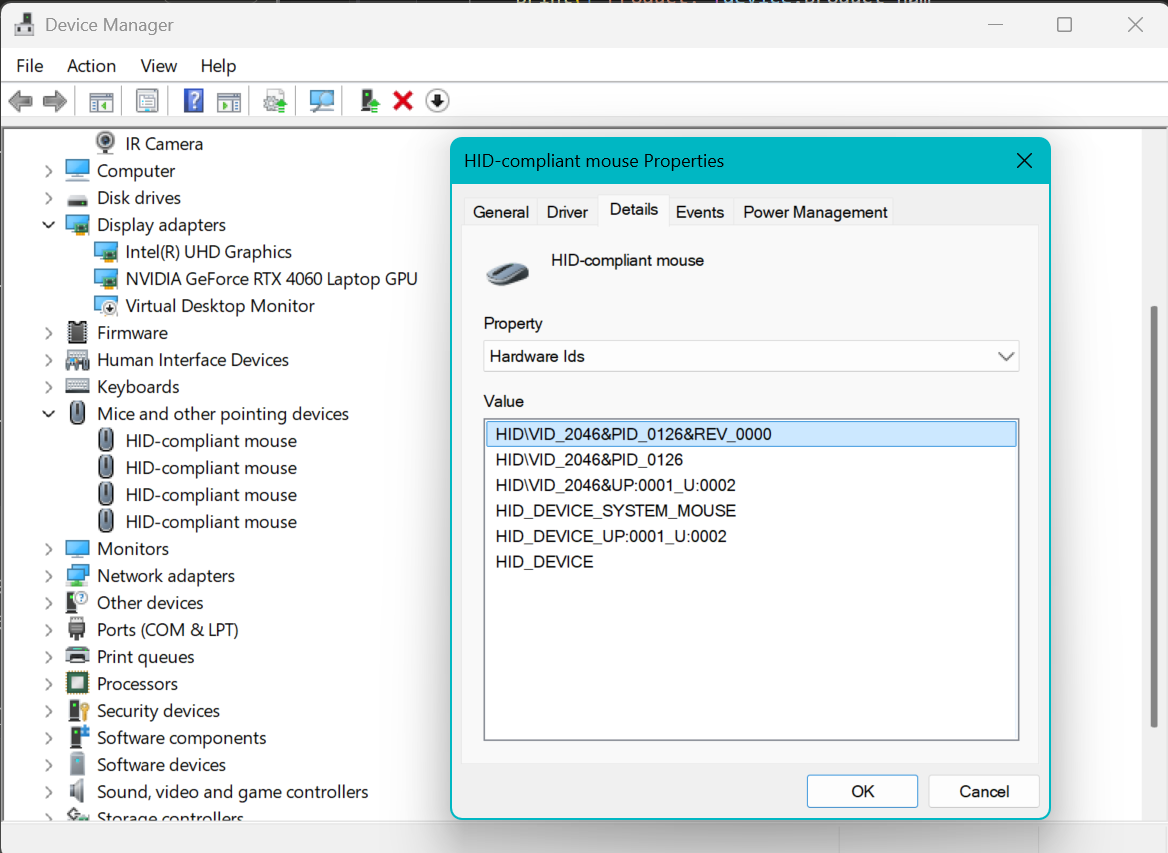

In [11]:
from IPython.display import Image, display
display(Image(filename='bigtrack-device-id.png', width=500))

https://claude.ai/share/97ad3709-f1fa-4b65-8c44-05cb7eb6ed02

libusb - fix

https://github.com/libusb/libusb/releases

Download libusb for Windows:

1. Go to: https://github.com/libusb/libusb/releases
2. Download `libusb-1.0.27.7z` (or latest version)
3. Extract it
4. Copy `VS2019\MS64\dll\libusb-1.0.dll` to your project folder or `C:\Windows\System32`

Then the PyUSB script should work.

In [1]:
import pywinusb.hid as hid
import time

# Find the Big Track
all_devices = hid.find_all_hid_devices()

bigtrack = None
for device in all_devices:
    if device.vendor_id == 0x2046 and device.product_id == 0x0126:
        bigtrack = device
        print(f"Found Big Track: {device.product_name}")
        break

if not bigtrack:
    print("Big Track not found!")
    exit()

# Callback to handle data
def data_handler(data):
    print(f"Raw data: {data}")

bigtrack.open()
bigtrack.set_raw_data_handler(data_handler)

print("Reading Big Track data... Move it around!")
print("Press Ctrl+C to stop")

try:
    while True:
        time.sleep(0.1)
except KeyboardInterrupt:
    print("\nStopped")
finally:
    bigtrack.close()

Big Track not found!


AttributeError: 'NoneType' object has no attribute 'open'

In [1]:
import pywinusb.hid as hid

print("All HID devices:\n")
all_devices = hid.find_all_hid_devices()

for device in all_devices:
    print(f"Product: {device.product_name}")
    print(f"Manufacturer: {device.vendor_name}")
    print(f"VID: 0x{device.vendor_id:04x}, PID: 0x{device.product_id:04x}")
    print("-" * 60)

All HID devices:

Product: @hidserv.inf,%hid_device_system_consumer%;HID-compliant consumer control device
Manufacturer: Unknown manufacturer
VID: 0x8087, PID: 0x0a1e
------------------------------------------------------------
Product: @input.inf,%hid_device_vendor_defined_range%;HID-compliant vendor-defined device
Manufacturer: Unknown manufacturer
VID: 0x8087, PID: 0x0a1e
------------------------------------------------------------
Product: @hidserv.inf,%hid_device_system_consumer%;HID-compliant consumer control device
Manufacturer: Unknown manufacturer
VID: 0x8087, PID: 0x0a1e
------------------------------------------------------------
Product: @hidserv.inf,%hid_device_system_consumer%;HID-compliant consumer control device
Manufacturer: Unknown manufacturer
VID: 0x8087, PID: 0x0a1e
------------------------------------------------------------
Product: @hidserv.inf,%hid_device_system_consumer%;HID-compliant consumer control device
Manufacturer: Unknown manufacturer
VID: 0x8087, PID:

## **Option 2: Install WinUSB Driver (with Zadig)**

Use **Zadig** tool to replace the driver with WinUSB:

1. Download Zadig: https://zadig.akeo.ie/
2. Run as Administrator
3. Options → List All Devices
4. Find "AbleNet Big Track 2" or device with VID 2046, PID 0126
5. Select "WinUSB" as the target driver
6. Click "Replace Driver"
7. Restart Computer for driver update to complete

**Warning:** This will make it NOT work as a mouse at all - only as a programmable device.

Alright, let's do it! Here's the step-by-step:
Zadig Installation:

Download Zadig: https://zadig.akeo.ie/
Run as Administrator (right-click → Run as administrator)
In Zadig, go to Options → List All Devices
In the dropdown at the top, look through the list for:

Something with "AbleNet" or "Big Track" in the name
OR look for (2046 0126) - the VID/PID in parentheses
OR just look for generic "USB Input Device" entries and we'll trial-and-error


Once you find it (or think you found it):

Left side should show current driver (probably "HIDClass" or similar)
Right side dropdown: select WinUSB
Click "Replace Driver" (or "Install Driver" if no driver currently)


Wait for it to finish
Unplug and replug the Big Track

After Installation:
The Big Track will no longer work as a mouse. Let's test if we can access it:
pythonimport usb.core
import usb.util

# Find the Big Track

In [2]:
import usb.core
import usb.util
import usb.backend.libusb1
import os

# Point to the DLL explicitly
backend = usb.backend.libusb1.get_backend(find_library=lambda x: os.path.join(os.getcwd(), "libusb-1.0.dll"))

# Find the Big Track using the backend
dev = usb.core.find(idVendor=0x2046, idProduct=0x0126, backend=backend)

if dev is None:
    print("Big Track not found!")
else:
    print(f"Found Big Track!")
    try:
        print(f"Manufacturer: {usb.util.get_string(dev, dev.iManufacturer)}")
        print(f"Product: {usb.util.get_string(dev, dev.iProduct)}")
    except:
        print("(Could not read device strings)")

Found Big Track!
Manufacturer: Nuvoton
Product: HIDse


In [1]:
import usb.core
import usb.util
import usb.backend.libusb1
import os

# Point to the DLL explicitly
backend = usb.backend.libusb1.get_backend(find_library=lambda x: os.path.join(os.getcwd(), "libusb-1.0.dll"))

# Find the Big Track
dev = usb.core.find(idVendor=0x2046, idProduct=0x0126, backend=backend)

if dev is None:
    print("Big Track not found!")
    exit()

print("Found Big Track!")

# Set configuration
dev.set_configuration()

# Get the endpoint
cfg = dev.get_active_configuration()
intf = cfg[(0,0)]
ep = usb.util.find_descriptor(
    intf,
    custom_match=lambda e: usb.util.endpoint_direction(e.bEndpointAddress) == usb.util.ENDPOINT_IN
)

print(f"Reading from endpoint: 0x{ep.bEndpointAddress:02x}")
print("Move the Big Track around! Press Ctrl+C to stop\n")

try:
    while True:
        try:
            data = dev.read(ep.bEndpointAddress, ep.wMaxPacketSize, timeout=100)
            if data:
                print(f"Raw: {list(data)} - Buttons: {data[0]}, X: {data[1]:+4d}, Y: {data[2]:+4d}")
        except usb.core.USBError as e:
            if e.args[0] != 110:  # Ignore timeout errors
                pass
except KeyboardInterrupt:
    print("\nStopped!")

Found Big Track!
Reading from endpoint: 0x81
Move the Big Track around! Press Ctrl+C to stop

Raw: [48, 0, 254, 0] - Buttons: 48, X:   +0, Y: +254
Raw: [48, 0, 255, 0] - Buttons: 48, X:   +0, Y: +255
Raw: [48, 0, 255, 0] - Buttons: 48, X:   +0, Y: +255
Raw: [48, 0, 255, 0] - Buttons: 48, X:   +0, Y: +255
Raw: [48, 0, 2, 0] - Buttons: 48, X:   +0, Y:   +2
Raw: [48, 0, 1, 0] - Buttons: 48, X:   +0, Y:   +1
Raw: [48, 0, 1, 0] - Buttons: 48, X:   +0, Y:   +1
Raw: [48, 0, 2, 0] - Buttons: 48, X:   +0, Y:   +2
Raw: [48, 0, 1, 0] - Buttons: 48, X:   +0, Y:   +1
Raw: [48, 0, 2, 0] - Buttons: 48, X:   +0, Y:   +2
Raw: [48, 0, 1, 0] - Buttons: 48, X:   +0, Y:   +1
Raw: [48, 0, 1, 0] - Buttons: 48, X:   +0, Y:   +1
Raw: [48, 0, 2, 0] - Buttons: 48, X:   +0, Y:   +2
Raw: [48, 0, 1, 0] - Buttons: 48, X:   +0, Y:   +1
Raw: [48, 0, 1, 0] - Buttons: 48, X:   +0, Y:   +1
Raw: [48, 0, 1, 0] - Buttons: 48, X:   +0, Y:   +1
Raw: [48, 0, 2, 0] - Buttons: 48, X:   +0, Y:   +2
Raw: [48, 0, 1, 0] - Buttons: 4

In [1]:
path = "assets/bigtrack/seeing-feelingly-through-the-feet-karolin-valaszkai.pdf"

from IPython.display import IFrame

IFrame(path, width=800, height=600)

In [ ]:
As a result, the designs, informed by the explorations, promote slowing down by connecting with your feet as the eyes of the body - concluding in the design
goal of bringing attention to the feet.

The definition signifies discovering tiny recurring moments throughout the day, a micro-opportunity, to be savored for a preferred state

The motivation through this research is to foreground the importance of the
feet, rather than seeing them as a low-status body part.

Our feet can be perceived as an entry point, much like our eyes, absorbing
information about our surroundings on a regular basis.

How could the feet as the eyes of the body open a space for design estrangement and micro opportunities?

Defamiliarization is utilized to revitalize perception
by disrupting our habitual ways of moving, sensing, and feeling to reorganize our sensory-motor neural pathways to tend
to the notion of estrangement 

When it comes to the aesthetic experience of an interaction,
instead of focusing solely on the sensory pleasure of its static
presence, Löwgren contends that it must address temporal
dimensions, attitudes, and how the interaction feels over time

## criticism
Visual feedback has a risk of diverting attention away from the
body and inner experiences, toward external objects and representations [1] or act as a constraint towards eyesight and keeping the eyes open [14]. Tactile and auditory communication,
on the other hand, offer promising opportunities for directing
attention to felt bodily experiences [1, 13, 14], encompassing
flexibility in terms of closed or open eyes. 
    - however antipodal juggling always had feet and visual involvement anyways.  So its not a pure nonvisual activity even without tech mediation.

http://elisevandenhoven.com/publications/feltham-tei14.pdf # slow floor
https://dl.acm.org/doi/10.1145/1935701.1935747 # balance board


In [2]:
from IPython.display import HTML

# List of YouTube URLs
youtube_urls = [
    'https://www.youtube.com/watch?v=-ebllmoLIf4',
    'https://www.youtube.com/watch?v=XyGfxCxnZW0',
    'https://www.youtube.com/watch?v=BA0MExlEmLo',
    'https://www.youtube.com/watch?v=naGntYNTSQM'
]

html = '<div style="display: flex; gap: 10px; flex-wrap: wrap;">'
width = 300
height = 225  # 16:9 aspect ratio for width=300

for url in youtube_urls:
    # Extract video ID from URL
    video_id = url.split('watch?v=')[-1].split('&')[0]
    
    html += f"""
    <figure style="text-align: center; margin: 0;">
        <iframe width="{width}" 
                height="{height}" 
                src="https://www.youtube.com/embed/{video_id}" 
                frameborder="0" 
                allow="autoplay; encrypted-media" 
                allowfullscreen
                style="border: 1px solid #ccc;">
        </iframe>
        <figcaption style="text-align: center; margin-top: 10px;">
            <a href="{url}">Watch on YouTube</a>
        </figcaption>
    </figure>
    """

html += '</div>'
HTML(html)

In [3]:
path = 'https://computerhistory.org/exhibits/technology-art/#:~:text=A%20sequence%20shows%20Catmull%20using,Catmull%20using%20the%20same%20techniques.'

from IPython.display import IFrame

IFrame(path, width=800, height=600)

In [ ]:
"A sequence shows Catmull using a mechanical digitizer to map and record positions using a movable arm and foot pedal"

In [ ]:
https://bogost.com/games/guru_meditation/
https://en.wikipedia.org/wiki/Joyboard

# Media Pipe